# 1. Setup & Environment
- 시계열 데이터 집계 및 학술 차트 렌더링 라이브러리 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 설정

In [1]:
# 1. 라이브러리 로드 및 환경 설정
from pathlib import Path
import json
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Chart Theme Definitions
- 원천 스냅샷, 아파트 필터, 2SFCA 산출물 디렉터리 경로 설정
- 평일 낮 단일 시나리오(11:00~13:00) 파라미터 및 학술 차트 컬러 팔레트 정의

In [2]:
# 2. 경로 및 분석 파라미터 설정
BASE_DIR = Path("/mnt/cowork/EV")
CHARGER_DIR_FASTONLY = BASE_DIR / "input/processed/yearly_snapshots_fastonly"
APT_FP = BASE_DIR / "output/apt_charger_flags/seoul_chargers_2024_apt_v3_final.csv"
DIR_GAUSSIAN = BASE_DIR / "output/g2sfca_sfast_final_gaussian"

DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)
OUT_PNG_MW = DIR_MAPS / "poster_timeseries_week_day_mw.png"

YEARS = [2021, 2022, 2023, 2024]
WINDOW_START, WINDOW_END = 11, 13  # 평일 낮 11:00 ~ 13:00
DAYTYPE = "week"

# 학술 논문 및 포스터 표준 컬러 팔레트
CHART_THEME = {
    "BAR_COLOR": "#2166ac",     # 유효 공급량 막대 (Academic Navy Blue)
    "LINE_COLOR": "#d73027",    # 접근성 지수 추세선 (Crimson Red)
    "REF_LINE": "#737373",      # 기준선 (Muted Gray)
    "TEXT": "#222222",          # 축 및 수치 라벨 텍스트
    "MUTED": "#666666",         # 서브타이틀 및 캡션
    "GRID": "#e0e0e0"           # 수평 보조선
}

print(f">> 분석 시계열: {YEARS}개년 | 기준 시나리오: 평일 낮 ({WINDOW_START}~{WINDOW_END}시)")
print(f">> 출력 대상 차트: {OUT_PNG_MW.name}")

>> 분석 시계열: [2021, 2022, 2023, 2024]개년 | 기준 시나리오: 평일 낮 (11~13시)
>> 출력 대상 차트: poster_timeseries_week_day_mw.png


# 3. Operating Hours Parser & Effective Supply Loader
- 충전소 운영시간 텍스트 정규식 파싱 및 분석 윈도우 개방 여부 판별 함수
- 아파트 소재 충전소 제외 및 유효 급속충전기/충전소 수 연도별 집계

In [3]:
# 3. 운영시간 파서 및 유효 공급 집계 엔진
TIME_RANGE_RE = re.compile(r"(\d{1,2})[:시](\d{2})?\s*[~-]\s*(\d{1,2})[:시](\d{2})?")

def parse_open_window(text: str):
    """운영시간 텍스트에서 시작/종료 시각 및 주중 전용 여부 추출"""
    if not text or not str(text).strip() or "24시간" in str(text) or "24시" in str(text):
        return None
    t = str(text).strip()
    m = TIME_RANGE_RE.search(t)
    if not m:
        return None
    h1, _, h2, _ = m.groups()
    start, end = int(h1), int(h2)
    weekday_only = ("평일" in t) or ("주중" in t)
    return (start, end, weekday_only)


def is_open(parsed, window_start: int, window_end: int, daytype: str = "week") -> bool:
    """평일 낮 분석 윈도우(11~13시) 내 충전소 실제 개방 여부 판정"""
    if parsed is None:
        return True
    start, end, weekday_only = parsed
    if weekday_only and daytype == "weekend":
        return False
    if end <= start:
        return True
    return not (end <= window_start or start >= window_end)


def load_effective_supply_by_year(years: list[int]) -> tuple[list[int], list[int]]:
    """아파트 제외 및 운영시간 필터가 적용된 연도별 유효 충전소/충전기 수 집계"""
    df_apt = pd.read_csv(APT_FP, dtype={"station_id": str})
    apt_set = set(df_apt[df_apt["is_apt_v3"]]["station_id"])
    
    n_stations, n_chargers = [], []
    
    for year in years:
        fname = f"metro7_ev_chargers_{year}_fastonly.geojson"
        fp = Path(unicodedata.normalize("NFD", str(CHARGER_DIR_FASTONLY / fname)))
        
        with open(fp, encoding="utf-8") as f:
            data = json.load(f)
            
        supply, hours = {}, {}
        for feat in data["features"]:
            p = feat["properties"]
            if p.get("city") == "서울특별시":
                sid = str(p["station_id"])
                supply[sid] = float(p.get("fast_count", 0) or 0)
                hours[sid] = parse_open_window(p.get("openinghour", ""))
                
        # 유효 충전소 필터링
        valid_sids = [
            sid for sid in supply
            if sid not in apt_set and is_open(hours.get(sid), WINDOW_START, WINDOW_END, DAYTYPE)
        ]
        
        st_cnt = len(valid_sids)
        chg_cnt = int(sum(supply[sid] for sid in valid_sids))
        
        n_stations.append(st_cnt)
        n_chargers.append(chg_cnt)
        print(f"  [>] {year}년 유효 급속충전소: {st_cnt:4,d}개소 | 유효 급속충전기: {chg_cnt:5,d}대")
        
    return n_stations, n_chargers

print("--- 연도별 유효 인프라 공급량 집계 ---")
stations_count, chargers_count = load_effective_supply_by_year(YEARS)

--- 연도별 유효 인프라 공급량 집계 ---
  [>] 2021년 유효 급속충전소:  444개소 | 유효 급속충전기:   892대
  [>] 2022년 유효 급속충전소:  689개소 | 유효 급속충전기: 1,609대
  [>] 2023년 유효 급속충전소: 1,102개소 | 유효 급속충전기: 2,912대
  [>] 2024년 유효 급속충전소: 1,376개소 | 유효 급속충전기: 3,737대


# 4. G2SFCA Accessibility Index Engine (2021=100 Median)
- 연도별 평일 낮 Gaussian 2SFCA 점수 로드 (`_mw.csv` 우선 참조)
- 2021년 기준 유효 접근성 집계구 대상 상대 인덱스 산출 및 중위값 도출

In [4]:
# 4. 2SFCA 접근성 상대 지수(2021=100) 연산
def resolve_score_path(year: int) -> Path:
    """2SFCA 점수 CSV 경로 탐색 (_mw 우선)"""
    fp_mw = DIR_GAUSSIAN / f"g2sfca_score_{year}_week_낮_normal_mw.csv"
    if fp_mw.exists():
        return fp_mw
    return DIR_GAUSSIAN / f"g2sfca_score_{year}_week_낮_normal.csv"

scores_by_year = {}
for year in YEARS:
    fp = resolve_score_path(year)
    s = pd.read_csv(fp, dtype={"oa_code": str}).set_index("oa_code")["accessibility_score"]
    scores_by_year[year] = s

# 2021년 점수가 0 초과인 집계구를 기준으로 상대 지수 계산
base_2021 = scores_by_year[2021]
valid_mask = base_2021 > 0

median_indices = []
for year in YEARS:
    idx_series = (scores_by_year[year][valid_mask] / base_2021[valid_mask]) * 100.0
    median_indices.append(idx_series.median())

print(f">> 2021년 기준 접근성 점수 인덱스 (중위값):")
for y, v in zip(YEARS, median_indices):
    print(f"   {y}년: {v:.1f} (기준 2021=100)")

>> 2021년 기준 접근성 점수 인덱스 (중위값):
   2021년: 100.0 (기준 2021=100)
   2022년: 180.3 (기준 2021=100)
   2023년: 334.8 (기준 2021=100)
   2024년: 444.2 (기준 2021=100)


# 5. Longitudinal Trends Summary Table
- 유효 급속충전기, 충전소 수 및 접근성 지수 연도별 요약 데이터프레임 구성

In [5]:
# 5. 시계열 변화 요약표 생성
df_timeseries = pd.DataFrame({
    "Year": YEARS,
    "Effective Stations (Sites)": stations_count,
    "Effective Fast Chargers (Units)": chargers_count,
    "Charger Growth vs 2021 (%)": [(c / chargers_count[0] - 1.0) * 100 for c in chargers_count],
    "G2SFCA Index (Median, 2021=100)": median_indices
})

print("=" * 85)
print("             평일 낮 기준 EV 충전 인프라 공급 및 접근성 시계열 추이 요약")
print("=" * 85)
display(df_timeseries)

             평일 낮 기준 EV 충전 인프라 공급 및 접근성 시계열 추이 요약


,Year,Effective Stations (Sites),Effective Fast Chargers (Units),Charger Growth vs 2021 (%),"G2SFCA Index (Median, 2021=100)"
0,2021,444,892,0.000000,100.000000
1,2022,689,1609,80.381166,180.338582
2,2023,1102,2912,226.457399,334.844970
3,2024,1376,3737,318.946188,444.245593


# 6. Dual-Panel Poster Chart Rendering & High-Res Export
- 좌측: 유효 급속충전기 및 충전소 수 연도별 증가 막대 차트 (Bar Chart)
- 우측: G2SFCA 접근성 점수 인덱스(중위값) 개선 추세선 차트 (Line Chart)
- 포스터 및 논문 발표 규격(300 DPI) 내보내기

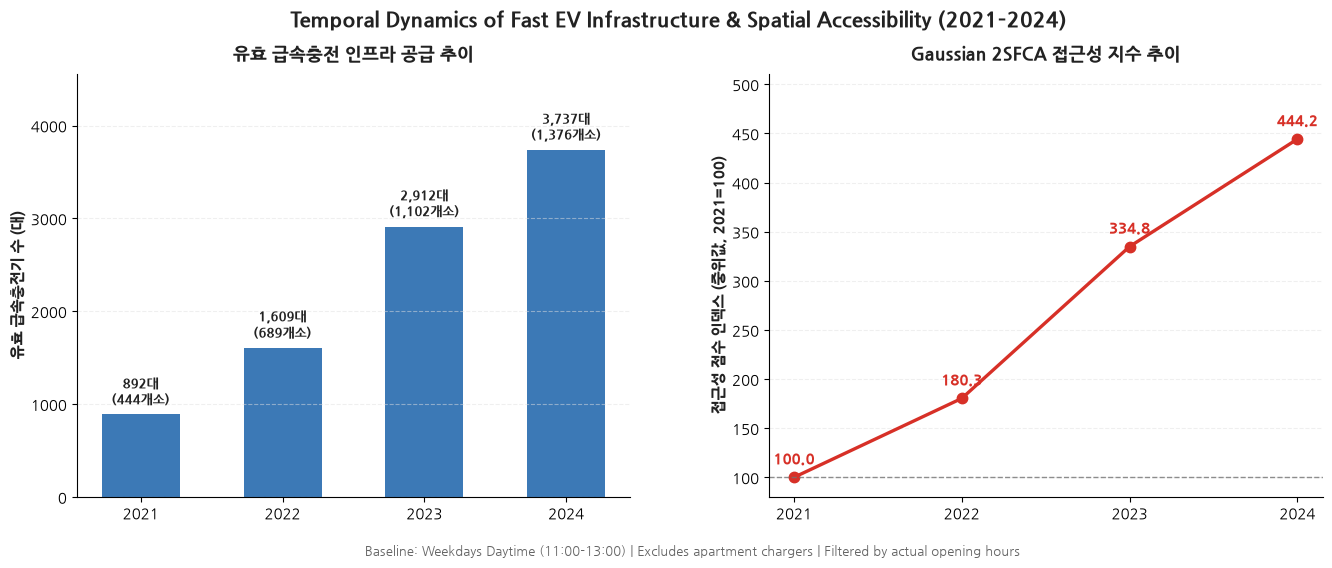

>> 시계열 분석 차트 고해상도 저장 완료: /mnt/cowork/EV/output/maps/poster_timeseries_week_day_mw.png


In [6]:
# 6. 이중 패널 시계열 차트 시각화 및 내보내기
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), facecolor="white")
plt.subplots_adjust(top=0.85, bottom=0.12, left=0.07, right=0.96, wspace=0.25)

# --- [패널 1] 연도별 유효 급속충전기 수 막대 차트 ---
ax1 = axes[0]
bars = ax1.bar(
    [str(y) for y in YEARS], 
    chargers_count, 
    color=CHART_THEME["BAR_COLOR"], 
    alpha=0.88, 
    width=0.55,
    edgecolor="none"
)

# 막대 상단 수치 라벨링 (충전기 수 / 충전소 수)
for b, n_s, n_c in zip(bars, stations_count, chargers_count):
    ax1.text(
        b.get_x() + b.get_width() / 2, 
        b.get_height() + max(chargers_count) * 0.02,
        f"{n_c:,}대\n({n_s:,}개소)", 
        ha="center", 
        va="bottom", 
        fontsize=9.5, 
        color=CHART_THEME["TEXT"],
        fontweight="bold",
        linespacing=1.2
    )

ax1.set_ylabel("유효 급속충전기 수 (대)", fontsize=11, fontweight="bold", color=CHART_THEME["TEXT"])
ax1.set_title("유효 급속충전 인프라 공급 추이", fontsize=13, fontweight="bold", color=CHART_THEME["TEXT"], pad=10)
ax1.set_ylim(0, max(chargers_count) * 1.22)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.5, color=CHART_THEME["GRID"])
ax1.tick_params(axis="both", labelsize=10.5)

# --- [패널 2] 2SFCA 접근성 지수 개선 추세선 차트 ---
ax2 = axes[1]
ax2.plot(
    YEARS, 
    median_indices, 
    marker="o", 
    color=CHART_THEME["LINE_COLOR"], 
    linewidth=2.4, 
    markersize=7.5,
    clip_on=False
)

# 데이터 포인트 라벨링
for x, y in zip(YEARS, median_indices):
    ax2.annotate(
        f"{y:.1f}", 
        (x, y), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha="center", 
        fontsize=10.5, 
        color=CHART_THEME["LINE_COLOR"], 
        fontweight="bold"
    )

# 2021년 기준선 (100) 점선 표기
ax2.axhline(100, color=CHART_THEME["REF_LINE"], linewidth=1.0, linestyle="--", alpha=0.8)
ax2.set_ylabel("접근성 점수 인덱스 (중위값, 2021=100)", fontsize=11, fontweight="bold", color=CHART_THEME["TEXT"])
ax2.set_title("Gaussian 2SFCA 접근성 지수 추이", fontsize=13, fontweight="bold", color=CHART_THEME["TEXT"], pad=10)
ax2.set_xticks(YEARS)
ax2.set_ylim(80, max(median_indices) * 1.15)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.5, color=CHART_THEME["GRID"])
ax2.tick_params(axis="both", labelsize=10.5)

# 전체 메인 타이틀 및 분석 윈도우 캡션
fig.suptitle(
    "Temporal Dynamics of Fast EV Infrastructure & Spatial Accessibility (2021–2024)", 
    fontsize=15, fontweight="bold", color=CHART_THEME["TEXT"], y=0.96
)
fig.text(
    0.51, 0.02, 
    "Baseline: Weekdays Daytime (11:00-13:00) | Excludes apartment chargers | Filtered by actual opening hours",
    ha="center", fontsize=9.5, color=CHART_THEME["MUTED"]
)

# 고해상도(300 DPI) 이미지 내보내기
fig.savefig(OUT_PNG_MW, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f">> 시계열 분석 차트 고해상도 저장 완료: {OUT_PNG_MW}")

# 7. Output Verification
- 생성된 300 DPI 고해상도 차트 이미지 파일의 경로 및 파일 크기(MB) 무결성 검증

In [7]:
# 7. 산출물 파일 상태 확인
if OUT_PNG_MW.exists():
    file_size_mb = OUT_PNG_MW.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_PNG_MW.name}")
    print(f"  절대 경로 : {OUT_PNG_MW.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 저장 완료 (포스터 및 논문 삽입 규격 충족)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_PNG_MW}")

  파일명    : poster_timeseries_week_day_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/poster_timeseries_week_day_mw.png
  파일 크기 : 0.25 MB
  상태      : 정상 저장 완료 (포스터 및 논문 삽입 규격 충족)
